# Variable selection

In this notebook we will explore how by selecting fewer bands we can improve our calibration models.

## Loading the data

In [1]:
import numpy as np

kiwi_spectra = np.loadtxt("results/kiwi_avg_spectra.csv", delimiter=",")
reference_values = np.loadtxt("data/reference.csv", delimiter=",")
wl = np.loadtxt("results/wavelengths.csv", delimiter=",")
reference_values = reference_values[:180, 0]

X = kiwi_spectra
y = reference_values

# Kennard stone partition data

In [2]:
import kennard_stone as ks

X_cal_ks, X_test_ks, y_cal_ks, y_test_ks = ks.train_test_split(kiwi_spectra, reference_values, test_size = 0.2, random_state=1)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/kennard_stone/_core/_core.py:313: IgnoredArgumentWarning: `random_state` is unnecessary since it is uniquely determined in this algorithm.
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-07-04 16:40:36,886 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-07-04 16:40:36,889 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sk

## Variable selection (COVSCL)

In [3]:
import numpy as np
from scipy import stats

def fcovsel_loo(X, y, A):
    """
    Parameters:
    X : numpy array of shape (n, p) - predictor matrix
    y : numpy array of shape (n, m) - response matrix  
    A : int - number of components
    
    Returns:
    RMSECV : list of arrays - RMSE for cross-validation for each response
    Ypreds : list of arrays - predictions for each response
    vars : array - selected variables
    """
    
    n = X.shape[0]
    vars_all = np.zeros((n, A), dtype=int)
    Xc = (np.sum(X, axis=0) - X) / (n - 1)  # Means without i-th sample
    yO = y.copy() 
    
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    
    T = np.zeros((n, A))
    q = np.zeros((y.shape[1], A))
    yc = (np.sum(y, axis=0) - y) / (n - 1)
    
    Ypreds = [np.zeros((n, A + 1)) for _ in range(y.shape[1])]
    n2 = np.zeros(n, dtype=bool)
    
    for i in range(n):
        inds2 = n2.copy()
        inds2[i] = True
        y_temp = yO - yc[i]
        X_temp = X.copy()
        X_temp = X_temp - Xc[i, :]
        X_temp_v = X_temp[i, :].copy()
        X_temp[inds2, :] = 0
        
        W = np.zeros((X.shape[1], A))
        
        for a in range(A):
            v = np.sum((X_temp.T @ y_temp) ** 2, axis=1)
            ind = np.argmax(v)
            vars_all[i, a] = ind
            
            W[ind, a] = 1
            t = X_temp @ W[:, a]
            
            if a > 0:
                t = t - T[:, :a] @ (T[:, :a].T @ t)
            
            t_norm = np.linalg.norm(t)
            if t_norm > 1e-12: #to avoid division by 0
                t = t / t_norm
            T[:, a] = t
            
            # Deflate y
            q[:, a] = y_temp.T @ t
            y_temp = y_temp - np.outer(t, t.T @ y_temp)
        
        # Calculate predictions
        for j in range(q.shape[0]):
            M = (X_temp.T @ T).T @ W
            M_upper = np.triu(M)
            R = W @ np.linalg.inv(M_upper)
            R_scaled = R * q[j, :].reshape(1, -1)
            beta = np.cumsum(R_scaled, axis=1)
            Ypreds[j][i, 1:] = X_temp_v @ beta
    
    # Get mode of selected variables across all iterations
    vars_final = stats.mode(vars_all, axis=0, keepdims=False)[0]
    
    RMSECV = []
    for j in range(len(Ypreds)):
        Ypreds[j] = Ypreds[j] + yc[:, j:j+1]
        if yO.ndim == 1:
            rmsecv = np.sqrt(np.mean((yO - Ypreds[j][:, 1:]) ** 2, axis=0))
        else:
            rmsecv = np.sqrt(np.mean((yO[:, j:j+1] - Ypreds[j][:, 1:]) ** 2, axis=0))
        RMSECV.append(rmsecv)
    
    return RMSECV, Ypreds, vars_final

In [16]:
y = np.expand_dims(reference_values, axis=1)
RMSECV, Ypreds, vars = fcovsel_loo(X, y, 50)

print("RMSECV:", RMSECV)
print("Ypreds:", Ypreds)
print("vars:", vars)


RMSECV: [array([1.70993218, 1.34824681, 1.32503239, 1.17492122, 1.15660558,
       1.12489891, 1.00189247, 0.97095465, 0.96201448, 0.90056199,
       0.88617422, 0.87029659, 0.77715924, 0.77698996, 0.73490594,
       0.71073341, 0.703871  , 0.69560667, 0.67851188, 0.68510168,
       0.66340941, 0.6365256 , 0.64872662, 0.63823905, 0.61782832,
       0.61610365, 0.61948159, 0.61822342, 0.61115178, 0.62037902,
       0.63215229, 0.63143011, 0.63929481, 0.63952239, 0.63778642,
       0.66138198, 0.66454784, 0.66163311, 0.65008547, 0.63299906,
       0.6301446 , 0.64963742, 0.63562411, 0.62155177, 0.61146062,
       0.62497119, 0.63392771, 0.63361256, 0.62844626, 0.62548434])]
Ypreds: [array([[17.0010838 , 17.52303608, 16.14013345, ..., 15.43581569,
        15.39912994, 15.38418209],
       [16.99624022, 17.02621989, 17.02424866, ..., 15.12476056,
        15.16364041, 15.18182374],
       [17.00187151, 16.8409924 , 15.99074164, ..., 15.18007352,
        15.16787361, 15.11091452],
       ...

## Predictive model based on selected variables

In [5]:
from sklearn.metrics import r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

def plot_cv_vs_test(y_cal, y_cv, y_test, y_test_pred, plot_titles=["Cross-Validated Predictions", "Test Predictions"]):
    """
    Plot a comparison of cross-validated vs. test set predictions.

    Parameters
    ----------
    y_cal : array-like, shape (n_samples_cal,)
        True target values for the calibration (training) set.
    y_cv : array-like, shape (n_samples_cal,)
        Cross-validated predicted values for the calibration set.
    y_test : array-like, shape (n_samples_test,)
        True target values for the test set.
    y_test_pred : array-like, shape (n_samples_test,)
        Predicted values for the test set.
    plot_titles : list of str (2), optional
        Plot titles to use.
    """
    # Compute metrics
    r2_cv = r2_score(y_cal, y_cv)
    rmse_cv = root_mean_squared_error(y_cal, y_cv)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Prepare figure
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Combined axis limits
    all_actual = np.concatenate([y_cal, y_test])
    all_pred = np.concatenate([y_cv, y_test_pred])
    vmin = min(all_actual.min(), all_pred.min())*0.95
    vmax = max(all_actual.max(), all_pred.max())*1.05

    # Plot CV
    axs[0].scatter(y_cal, y_cv, alpha=0.6)
    axs[0].plot([vmin, vmax], [vmin, vmax], 'k--', lw=2)
    axs[0].set_title(plot_titles[0])
    axs[0].set_xlabel('Actual')
    axs[0].set_ylabel('Predicted')
    axs[0].set_aspect('equal', 'box')
    axs[0].text(0.05, 0.95, f"R² = {r2_cv:.2f}\nRMSE = {rmse_cv:.2f}",
                transform=axs[0].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Plot Test
    axs[1].scatter(y_test, y_test_pred, alpha=0.6, color='orange')
    axs[1].plot([vmin, vmax], [vmin, vmax], 'k--', lw=2)
    axs[1].set_title(plot_titles[1])
    axs[1].set_xlabel('Actual')
    axs[1].set_ylabel('Predicted')
    axs[1].set_aspect('equal', 'box')
    axs[1].text(0.05, 0.95, f"R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}",
                transform=axs[1].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Set same limits
    for ax in axs:
        ax.set_xlim(vmin, vmax)
        ax.set_ylim(vmin, vmax)

    plt.tight_layout()
    plt.show()

Results of normal PLS


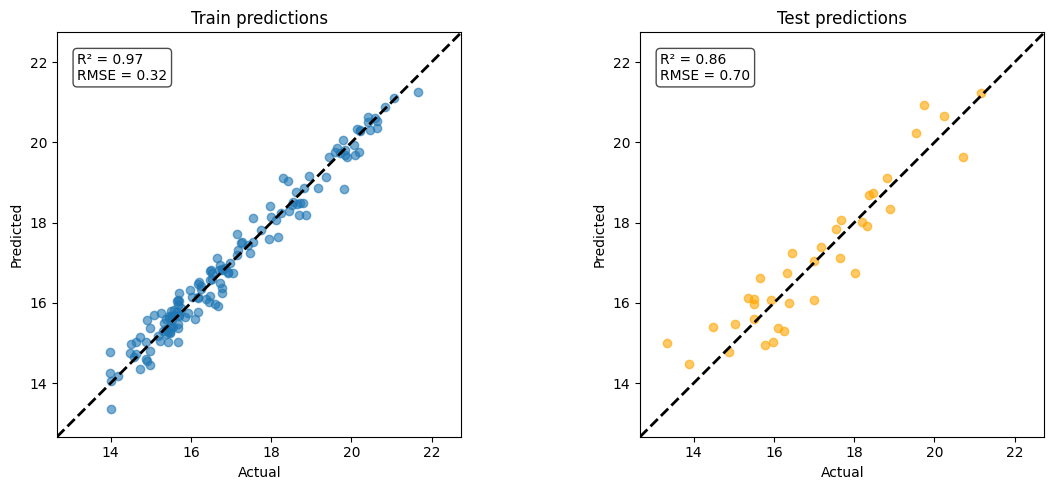

In [19]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=30)
pls.fit(X_cal_ks,y_cal_ks)
y_pred_pls_cv = pls.predict(X_cal_ks)
y_pred_pls_test = pls.predict(X_test_ks)
print("Results of normal PLS")
plot_cv_vs_test(y_cal_ks, y_pred_pls_cv, y_test_ks, y_pred_pls_test, plot_titles=["Train predictions", "Test predictions"])


Results of PLS regression on data with just a few selected bands


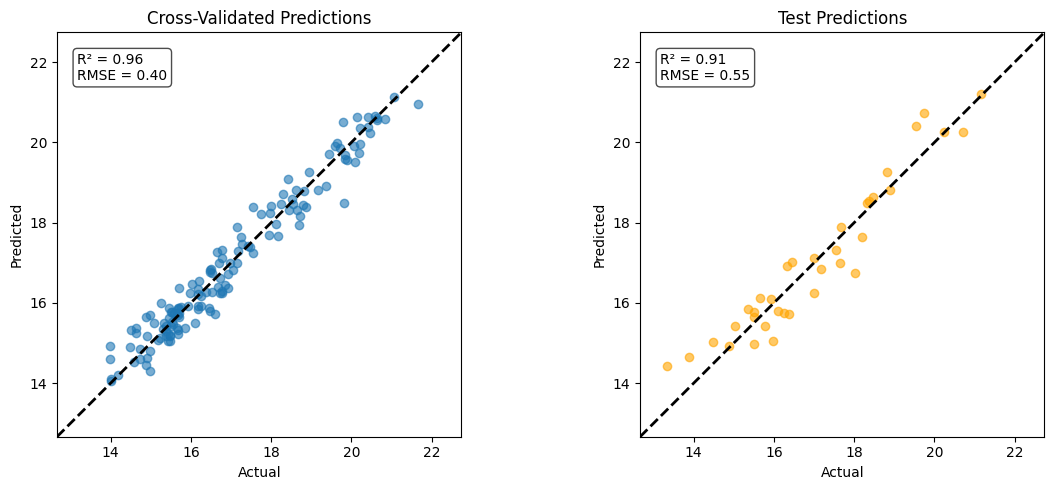

In [20]:
X_cal_reduced = X_cal_ks[:, vars]
X_test_reduced = X_test_ks[:, vars]
pls = PLSRegression(n_components=30)
pls.fit(X_cal_reduced, y_cal_ks)
y_pred_pls_cv = pls.predict(X_cal_reduced)
y_pred_pls_test = pls.predict(X_test_reduced)
print("Results of PLS regression on data with just a few selected bands")
plot_cv_vs_test(y_cal_ks, y_pred_pls_cv, y_test_ks, y_pred_pls_test)

Models with fewer components usually are less biased, so on unseen data they perform better.